# T2 — Secondary air experiments: how to recommend secondary air (and from it the AFR)

**Plant request.** Recommend the **secondary air flow**, then derive the air-fuel ratio from it: `AFR = secondary air ÷ NG` (both in workbook units).

**Questions**
1. What does secondary air actually follow: the gas **volume** (SCM) or the gas **heat** (SCM × NCV)? Physically, the oxygen needed depends on the heat (energy) burned, not on the volume.
2. Which formula best reproduces the air operators actually set (hourly, walk-forward)?
3. Which air level is **efficient** and still safe without an O₂ analyser?

**Data:** hourly table, hours with valid NCV, gas and air. Test folds: Mar–May 2026 and Jun–Aug 2026; each day is predicted from the 45 days before it. **Crown temperatures are not used:** air is a combustion-ratio question.

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import warnings
h = pd.read_parquet(dp.PROCESSED / 'hourly_clean.parquet')
d = pd.read_parquet(dp.PROCESSED / 'daily_clean.parquet')
h = h.dropna(subset=['sec_air', 'ng_scm', 'gas_kcal', 'ncv']).copy()
h['heat_mcal'] = h.gas_kcal / 1e3
FOLDS = {'Mar-May 2026': ('2026-03-01', '2026-05-31'), 'Jun-Aug 2026': ('2026-06-01', '2026-08-31')}
print('hours used:', len(h), h.index.min().date(), '->', h.index.max().date())

hours used: 8250 2025-10-10 -> 2026-09-30


## 1. What does secondary air follow?

,model,R2,Intercept,ng_scm,heat_mcal,ncv
0,sec_air ~ ng_scm,0.4427,2329.7305,5.1786,NaN,NaN
1,sec_air ~ heat_mcal,0.6581,430.4162,NaN,1.1334,NaN
2,sec_air ~ heat_mcal + ncv,0.7126,1168.3007,NaN,1.1362,-0.0777
3,sec_air ~ ng_scm + ncv,0.7219,-2424.0433,10.8213,NaN,0.2987


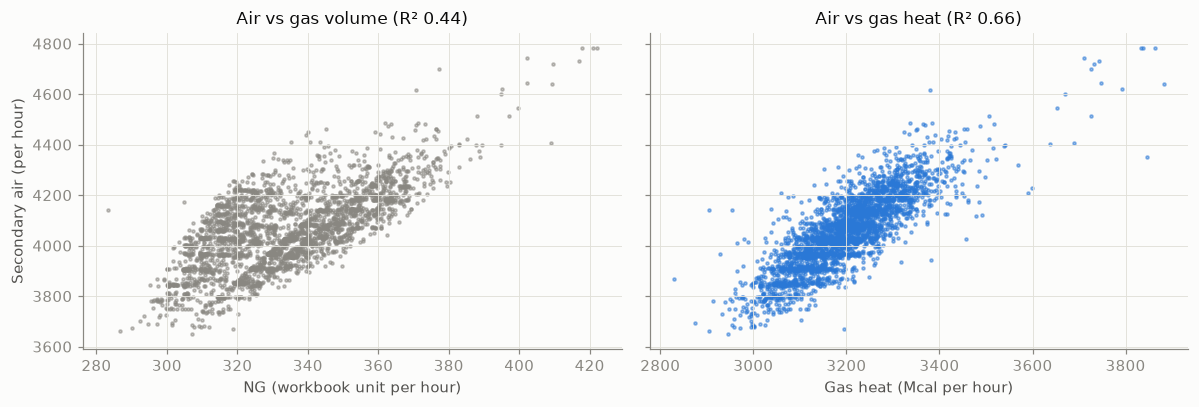

In [2]:
fits = []
for f in ['sec_air ~ ng_scm', 'sec_air ~ heat_mcal', 'sec_air ~ heat_mcal + ncv', 'sec_air ~ ng_scm + ncv']:
    m = smf.ols(f, h).fit(); fits.append(dict(model=f, R2=m.rsquared, **{k: v for k, v in m.params.items()}))
display(pd.DataFrame(fits).round(4))
smp = h.sample(3000, random_state=1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
ax[0].scatter(smp.ng_scm, smp.sec_air, s=4, color=MUTED, alpha=0.5); ax[0].set_xlabel('NG (workbook unit per hour)'); ax[0].set_ylabel('Secondary air (per hour)')
ax[0].set_title('Air vs gas volume (R² %.2f)' % smf.ols('sec_air ~ ng_scm', h).fit().rsquared)
ax[1].scatter(smp.heat_mcal, smp.sec_air, s=4, color=BLUE, alpha=0.5); ax[1].set_xlabel('Gas heat (Mcal per hour)')
ax[1].set_title('Air vs gas heat (R² %.2f)' % smf.ols('sec_air ~ heat_mcal', h).fit().rsquared)
plt.tight_layout(); plt.show()

**Reading 1.** Secondary air follows the **heat** much better than the gas volume. When NCV rises, operators already raise the air for the same gas volume, because richer gas needs more oxygen. So the right control quantity is **air per Mcal of gas heat**, not a fixed AFR.

## 2. Which formula reproduces the actual air best? (walk-forward, hourly)
| Approach | Formula (parameters from the last 45 days) |
|---|---|
| A1 constant AFR | air = median AFR × NG |
| A2 constant air per Mcal | air = median (air/Mcal) × gas heat |
| A3 regression on heat + NCV | air = a + b·heat + c·NCV |
| A4 regression on heat | air = a + b·heat |

In [3]:
warnings.simplefilter('ignore')
rows = []
for fold, (a, b) in FOLDS.items():
    te = h[a:b]; err = {k: [] for k in ['A1 constant AFR', 'A2 constant air per Mcal', 'A3 regression heat + NCV', 'A4 regression heat']}
    for day in te.index.normalize().unique():
        tr = h[(h.index < day) & (h.index >= day - pd.Timedelta(days=45))]; x = te[te.index.normalize() == day]
        err['A1 constant AFR'].append(x.sec_air - (tr.sec_air / tr.ng_scm).median() * x.ng_scm)
        err['A2 constant air per Mcal'].append(x.sec_air - (tr.sec_air / tr.heat_mcal).median() * x.heat_mcal)
        err['A3 regression heat + NCV'].append(x.sec_air - smf.ols('sec_air ~ heat_mcal + ncv', tr).fit().predict(x))
        err['A4 regression heat'].append(x.sec_air - smf.ols('sec_air ~ heat_mcal', tr).fit().predict(x))
    for k, v in err.items():
        e = pd.concat(v); rows.append(dict(fold=fold, approach=k, mae_pct_of_air=100 * e.abs().mean() / te.sec_air.mean(), bias_pct=100 * e.mean() / te.sec_air.mean()))
R = pd.DataFrame(rows)
piv = R.pivot_table(index='approach', columns='fold', values='mae_pct_of_air').round(2); piv['average'] = piv.mean(axis=1).round(2)
piv.sort_values('average')

fold,Jun-Aug 2026,Mar-May 2026,average
approach,,,
A3 regression heat + NCV,1.54,1.29,1.42
A4 regression heat,1.57,1.33,1.45
A2 constant air per Mcal,1.65,1.35,1.50
A1 constant AFR,3.78,2.85,3.32


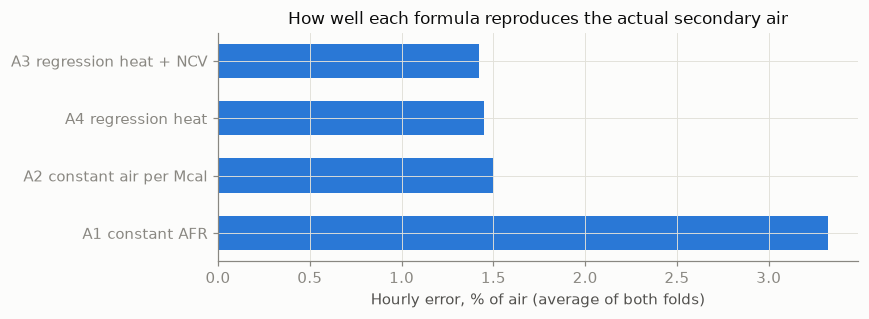

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(piv.sort_values('average').index, piv.sort_values('average').average, color=BLUE, height=0.6); ax.invert_yaxis()
ax.set_xlabel('Hourly error, % of air (average of both folds)'); ax.set_title('How well each formula reproduces the actual secondary air')
plt.tight_layout(); plt.show()

**Reading 2.**
- A constant AFR (A1) is clearly worst: about twice the error, because it ignores NCV.
- A constant air per Mcal (A2) is almost as good as the regressions (A3, A4). It also has a physical meaning (oxygen per unit of heat) and no intercept that could give odd values at low firing.
- **Choice: A2.** `secondary air = air_per_Mcal × gas heat`.

## 3. Which air-per-Mcal target? Efficiency vs safety (no O₂ analyser)

In [5]:
u = d[d.usable].copy(); u['age_m'] = (u.index - pd.Timestamp('2025-09-01')).days / 30.44
u['E_g'] = u.energy_kcal / 1e6
mB = smf.ols('E_g ~ draw_t + cullet_pct + age_m', u[u.in_baseline]).fit()
u['resid'] = u.E_g - mB.predict(u)
ma = smf.ols('resid ~ air_per_mcal', u).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
apm = h.sec_air / h.heat_mcal
qs = apm.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75])
tab = pd.DataFrame({'air per Mcal': qs.values,
                    'energy saving vs median (%)': [ma.params.air_per_mcal * (apm.median() - v) / u.E_g.mean() * 100 for v in qs.values]},
                   index=['P1', 'P5', 'P10', 'P25', 'median', 'P75'])
print('Energy residual per +0.01 SCM/Mcal: %+.2f Gcal/day (p %.3f)' % (ma.params.air_per_mcal / 100, ma.pvalues.air_per_mcal))
tab.round(3)

Energy residual per +0.01 SCM/Mcal: +0.14 Gcal/day (p 0.008)


,air per Mcal,energy saving vs median (%)
P1,1.204,0.997
P5,1.226,0.662
P10,1.236,0.498
P25,1.252,0.258
median,1.268,0.000
P75,1.284,-0.250


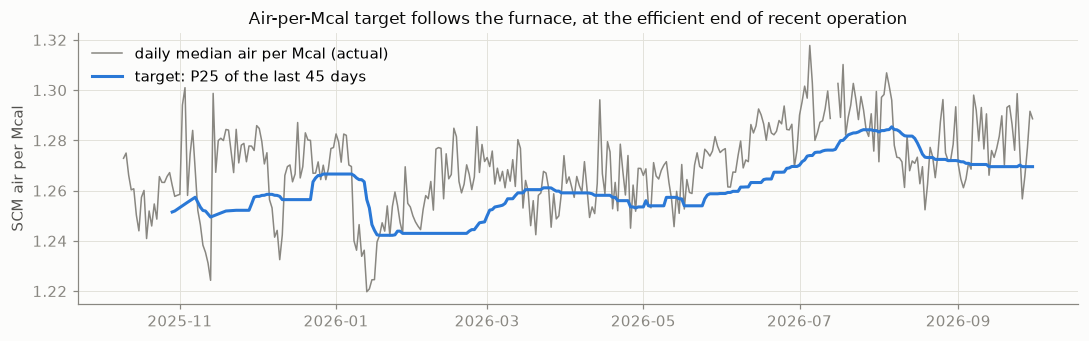

In [6]:
roll = (h.sec_air / h.heat_mcal).resample('D').median().rolling(45, min_periods=20).quantile(0.25)
fig, ax = plt.subplots(figsize=(10, 3.2))
dd = (h.sec_air / h.heat_mcal).resample('D').median()
ax.plot(dd.index, dd.values, color=MUTED, lw=1, label='daily median air per Mcal (actual)')
ax.plot(roll.index, roll.values, color=BLUE, lw=2, label='target: P25 of the last 45 days')
ax.set_ylabel('SCM air per Mcal'); ax.legend(loc='upper left'); ax.set_title('Air-per-Mcal target follows the furnace, at the efficient end of recent operation')
plt.tight_layout(); plt.show()

**Reading 3.**
- Less air per Mcal → less energy (significant within the historical range).
- **Without O₂ measurement, the target must stay inside proven operation.** Two options:
  - **rolling P25 of the last 45 days** (shown in the chart): follows the furnace as it changes, and is always a level the furnace has just run at
  - **fixed historical P25** (≈1.258)

  The rolling P25 is chosen. A hard floor at the historical **P5** guards against ever going lower than proven.
- Going to P10 or P5 would save more, but **only with an O₂ analyser** to confirm complete combustion (no CO).

## Decision: secondary air recommendation
```
heat_rec      = gas heat of this 15-min interval (from Model 1)           [kcal]
air_per_mcal  = max(P25 of daily air/Mcal over the last 45 days, historical P5)
sec_air_rec   = air_per_mcal × heat_rec / 1000                           [workbook unit, per 15 min]
AFR_rec       = sec_air_rec / NG_rec                                     (= air_per_mcal × NCV / 1000)
```
- AFR is clipped to its historical P1–P99.
- Crown temperatures are not used: air is a combustion-ratio decision.

In [7]:
out = pd.DataFrame({'P25_rolling_45d_latest': [roll.dropna().iloc[-1]], 'hist_P5_floor': [apm.quantile(0.05)], 'hist_P25': [apm.quantile(0.25)]})
out.to_csv(dp.PROCESSED / 'training_air_targets.csv', index=False)
out.round(3)

,P25_rolling_45d_latest,hist_P5_floor,hist_P25
0,1.27,1.226,1.252
